In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define SNR and MSE for Evaluation

In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu.astype(np.float32))
    ns = sigma_s/sigma_n
    snr = 10 * np.log10(ns)
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

#Load Peper Image and Plot It

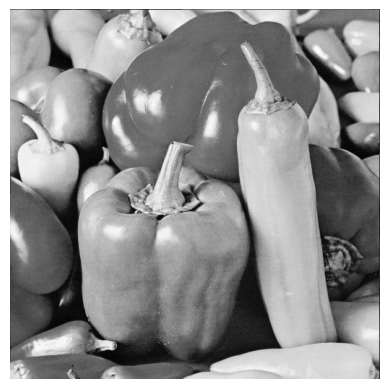

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/Peppers.mat')['peppers']

# plot image
plt.imshow(img,cmap='gray')
plt.axis('off');

# Perform 2D-DCT on Peper Image

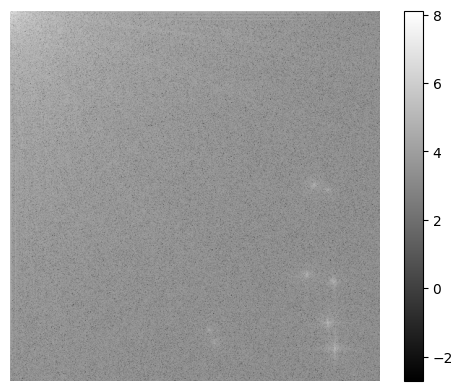

In [ ]:
from scipy.fftpack import dct

# take 2D-DCT
img_dct = dct(dct(img, axis=0), axis=1)

# The scale is not good due to strong components (e.g. the 0,0 DC component).
# Here we take logarithmic scale
im = plt.imshow(np.log10(np.abs(img_dct)),cmap='gray')
plt.axis('off')
plt.colorbar(im)

# Perform Inverse 2D-DCT

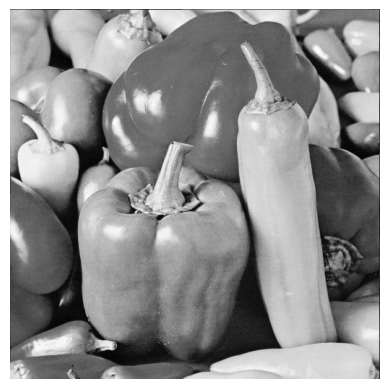

In [ ]:
from scipy.fftpack import idct

# take 2D-iDCT
img_idct = idct(idct(img_dct, axis=0), axis=1)

im = plt.imshow(img_idct,cmap='gray')
plt.axis('off');

# Perform 2D-DCT using Blocks and Thresholds


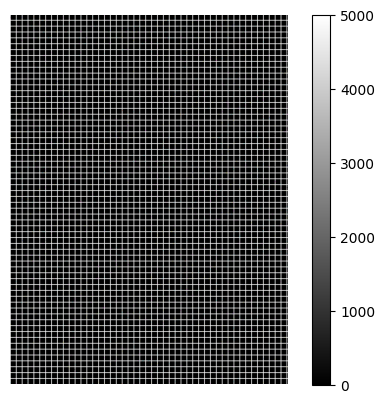

In [ ]:
from scipy.fftpack import dct

dct_coeff = np.zeros((img.shape))

block_size = 16

for i in range(0, img.shape[0], block_size):
  for j in range(0, img.shape[1], block_size):
    dct_coeff[i:i+block_size, j:j+block_size] = dct(dct(img[i:i+block_size, j:j+block_size], axis=0), axis=1)
    # if only retain top-left coefficient for each block
    dct_coeff[i+2:i+block_size, j+2:j+block_size] = 0

im = plt.imshow((np.abs(dct_coeff)),cmap='gray', vmax = 5000)

plt.axis('off')
plt.colorbar(im)

# Perform Inverse 2D-DCT Block-Wise


SNR: 18.46
MSE: 526.04


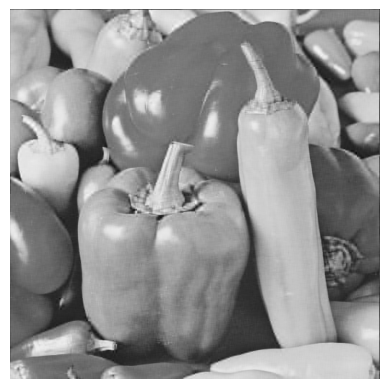

In [ ]:
from scipy.fftpack import idct
import cv2

img_idct = np.zeros((dct_coeff.shape))

block_size = 16

for i in range(0, dct_coeff.shape[0], block_size):
  for j in range(0, dct_coeff.shape[1], block_size):
    img_idct[i:i+block_size, j:j+block_size] = idct(idct(dct_coeff[i:i+block_size, j:j+block_size], axis=0), axis=1)

# convert to uint8
norm_image = cv2.normalize(img_idct, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F).astype('int')
plt.figure()
plt.imshow(norm_image, cmap='gray')
plt.axis('off');

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, norm_image),2))
print('MSE:', np.round(MSE(img, norm_image), 2))

# Load Dog Image and Plot it

(np.float64(-0.5), np.float64(755.5), np.float64(1007.5), np.float64(-0.5))

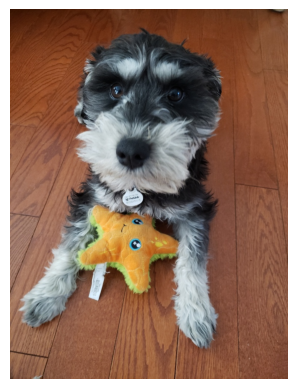

In [ ]:
from matplotlib import image
import numpy as np

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/Chapter 6 Image Transforms/'

# load image
img = image.imread(work_path + '/Data/Dog.jpg')
img = np.transpose(img, (0,1,2))

# plot image
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')

# Perform 2D-DCT

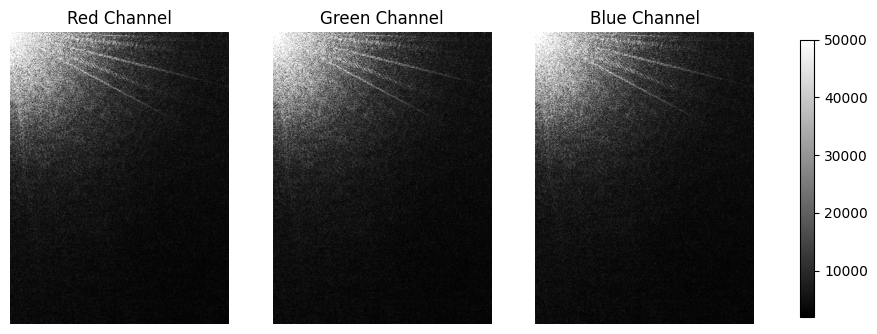

In [ ]:
from scipy.fftpack import dct

# take 2D-DCT
img_dct = dct(dct(img, axis=0), axis=1)

fig, ax = plt.subplots(1, 3, figsize=(12, 8))

# red channel
im = ax[0].imshow(np.abs(img_dct[:,:,0]),cmap='gray', vmax = 50000, vmin=2000)
ax[0].set_title('Red Channel')
ax[0].axis('off')

# green channel
im = ax[1].imshow(np.abs(img_dct[:,:,1]),cmap='gray', vmax = 50000, vmin=2000)
ax[1].set_title('Green Channel')
ax[1].axis('off')

# blue channel
im = ax[2].imshow(np.abs(img_dct[:,:,2]),cmap='gray', vmax = 50000, vmin=2000)
ax[2].set_title('Blue Channel')
ax[2].axis('off')

fig.colorbar(im, ax=ax.ravel().tolist(), shrink = 0.45)

# Perform Inverse 2D-DCT

<Figure size 640x480 with 0 Axes>

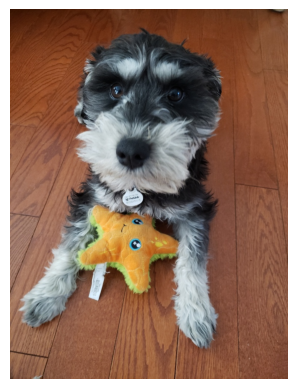

In [ ]:
from scipy.fftpack import idct
import cv2

# take 2D-iDCT
plt.figure()
img_idct = idct(idct(img_dct, axis=0), axis=1)
norm_image = cv2.normalize(img_idct, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
plt.figure()
im = plt.imshow(norm_image.astype(np.uint8))
plt.axis('off');

# Perform 2D-DCT using Blocks



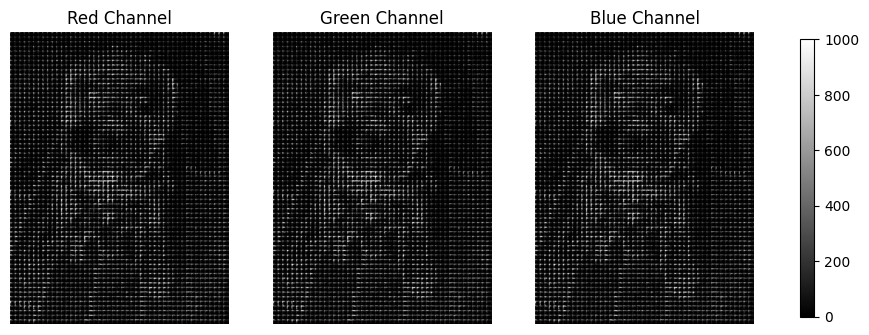

In [ ]:
from scipy.fftpack import dct

dct_coeff = np.zeros((img.shape))

block_size = 16

for i in range(0, img.shape[0], block_size):
  for j in range(0, img.shape[1], block_size):
    dct_coeff[i:i+block_size, j:j+block_size] = dct(dct(img[i:i+block_size, j:j+block_size], axis=0), axis=1)
    # if only retain top-left coefficient for each block
    dct_coeff[i+4:i+block_size, j+4:j+block_size] = 0


fig, ax = plt.subplots(1, 3, figsize=(12, 8))

im = ax[0].imshow(np.abs(dct_coeff[:,:,0]), cmap='gray', vmax=1000, vmin=0)
ax[0].set_title('Red Channel')
ax[0].axis('off')

im = ax[1].imshow(np.abs(dct_coeff[:,:,1]), cmap='gray', vmax=1000, vmin=0)
ax[1].set_title('Green Channel')
ax[1].axis('off')

im = ax[2].imshow(np.abs(dct_coeff[:,:,2]), cmap='gray', vmax=1000, vmin=0)
ax[2].set_title('Blue Channel')
ax[2].axis('off')

fig.colorbar(im, ax=ax.ravel().tolist(), shrink = 0.45)

# Perform Inverse 2D-DCT Block-Wise

SNR: 14.43
MSE: 118.35


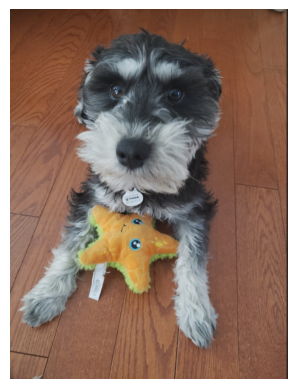

In [ ]:
from scipy.fftpack import idct
import cv2

# take 2D-iDCT
img_idct = np.zeros((dct_coeff.shape))
block_size = 16

for i in range(0, dct_coeff.shape[0], block_size):
  for j in range(0, dct_coeff.shape[1], block_size):
    img_idct[i:i+block_size, j:j+block_size] = idct(idct(dct_coeff[i:i+block_size, j:j+block_size], axis=0), axis=1)

# convert to uint8
norm_image = cv2.normalize(img_idct, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F).astype('int')
plt.figure()
plt.imshow(norm_image)
plt.axis('off');

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, norm_image),2))
print('MSE:', np.round(MSE(img, norm_image), 2))